# Problem 1

In [1]:
import numpy as np
import numpy.linalg as lin
import matplotlib.pyplot as plt

In [2]:
def QR_decompose(A):
    # Function for QR decomposition using Gram-Schmidt process
    # A: input, a real square matrix

    n, m = np.shape(A)
    # A = Q@R
    A = A.astype(float) # turn int -> float
    Q = np.zeros_like(A) # orthogonal matrix
    R = np.zeros_like(A) # upper-triangular matrix

    for i in range(n):
        a_i = np.copy(A[:, i])
        u = np.copy(a_i)

        for j in range(i):
            q_j = np.copy(Q[:, j])
            u -= q_j*(q_j@a_i)
            R[j, i] = q_j@a_i

        Q[:, i] = u/lin.norm(u)
        R[i, i] = lin.norm(u)

    return Q, R


A = np.array([[1, 4, 8, 4],
              [4, 2, 3, 7],
              [8, 3, 6, 9],
              [4, 7, 9, 2]])

q, r = QR_decompose(A)
print(q@r)

[[1. 4. 8. 4.]
 [4. 2. 3. 7.]
 [8. 3. 6. 9.]
 [4. 7. 9. 2.]]


In [3]:
def QR_algorithm(A, c=1E-6):
    # Solving eigenvalue problem using QR decomposition
    # A: input, a real square matrix
    # c: stop condition

    A_k = np.copy(A).astype(float)
    mask = ~np.eye(np.shape(A)[0], dtype=bool) # for checking non-diagonal elements
    
    V = np.eye(np.shape(A)[0], dtype=float) # matrix for eigenvectors
    
    while True:
        Q, R = QR_decompose(A_k)
        A_k = R@Q
        V = V@Q

        nondiag = A_k[mask]

        if np.all(np.abs(nondiag) < c):
            break

    return A_k, V


A_QR, V = QR_algorithm(A)
E = np.diag(A_QR) # eigenvalues

print("A_QR:")
print(A_QR)
print(f"\nEigenvalues: {E}")

print("\nEigenvectors:")
for i, e in enumerate(E):
    print(f"v_{i}={V[:, i]}")

for i, e in enumerate(E):
    print(f"\nλv_{i}={e*V[:, i]}")
    print(f"Av_{i}={(A@V)[:, i]}")


A_QR:
[[ 2.10000000e+01  7.36067983e-07  2.00505365e-14 -4.44738475e-14]
 [ 7.36067998e-07 -8.00000000e+00  5.99038894e-08 -4.92772067e-15]
 [ 1.76373367e-14  5.99038974e-08 -3.00000000e+00 -2.06494012e-08]
 [ 5.69063112e-23  9.58659066e-16 -2.06493983e-08  1.00000000e+00]]

Eigenvalues: [21. -8. -3.  1.]

Eigenvectors:
v_0=[0.43151698 0.38357063 0.62330228 0.52740965]
v_1=[-0.38357064  0.43151698  0.52740965 -0.62330227]
v_2=[-0.77459666 -0.2581989   0.25819889  0.51639779]
v_3=[-0.25819889  0.77459667 -0.51639778  0.25819889]

λv_0=[ 9.0618566   8.05498323 13.08934785 11.0756026 ]
Av_0=[ 9.06185632  8.05498355 13.08934824 11.07560214]

λv_1=[ 3.06856512 -3.45213582 -4.2192772   4.98641818]
Av_1=[ 3.06856539 -3.45213556 -4.21927673  4.9864186 ]

λv_2=[ 2.32378999  0.7745967  -0.77459666 -1.54919336]
Av_2=[ 2.32378997  0.77459671 -0.77459662 -1.5491934 ]

λv_3=[-0.25819889  0.77459667 -0.51639778  0.25819889]
Av_3=[-0.25819888  0.77459667 -0.51639778  0.25819888]


# Problem 2

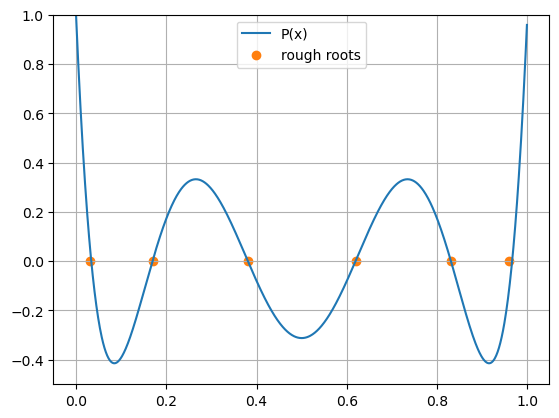

Rough values for the roots: [0.03 0.17 0.38 0.62 0.83 0.96]
Exact values for the roots: [0.03376524 0.16939531 0.38069041 0.61930959 0.83060469 0.96623476]

Initial guessing of root: 0.03
1: 0.033576198441077475 |dx|=0.0035761984410774745
2: 0.03376473401628287 |dx|=0.00018853557520539615
3: 0.033765242894723296 |dx|=5.088784404312551e-07
4: 0.03376524289842399 |dx|=3.7006912036074105e-12

Root=0.03376524289842399

Exact value of root: 0.033765242898423864
Difference=1.249000902703301e-16
Initial guessing of root: 0.17
1: 0.1693944274297977 |dx|=0.0006055725702023104
2: 0.16939530676505088 |dx|=8.793352531554711e-07
3: 0.16939530676686768 |dx|=1.8168047466335833e-12

Root=0.16939530676686768

Exact value of root: 0.1693953067668677
Difference=-2.7755575615628914e-17
Initial guessing of root: 0.38
1: 0.38069018429439055 |dx|=0.0006901842943905465
2: 0.38069040695837275 |dx|=2.2266398221914548e-07
3: 0.38069040695840195 |dx|=2.92035813676763e-14

Root=0.38069040695840195

Exact value of 

In [4]:
# 2-1


def P(x): 
    return 924*x**6 - 2772*x**5 + 3150*x**4 - 1680*x**3 + 420*x**2 - 42*x + 1


def dP(x): 
    return 5544*x**5 - 13860*x**4 + 12600*x**3 - 5040*x**2 + 840*x - 42 # dP(x)/dx


def rootNewton(f, df, x0, e=1E-11):
    # Find root using Newton method
    # f: f(x) = 0
    # df: df/df
    # x0: initial guess of root
    # e: Loop stops when |dx| <= e

    dx = 1
    i = 0

    while np.abs(dx) > e:
        dx = f(x0)/df(x0)
        x0 -= dx
        i += 1
        print(f"{i}: {x0} |dx|={np.abs(dx)}")

    return x0


x = np.arange(0, 1, 0.001)
y = P(x)

root_rough = np.array([0.03, 0.17, 0.38, 0.62, 0.83, 0.96])
root_true = (np.polynomial.legendre.legroots(np.polynomial.legendre.Legendre.basis(6).coef)+1)/2 # Exact value of roots

plt.plot(x, y, label='P(x)')
plt.ylim(-0.5, 1)
plt.scatter(root_rough, np.zeros_like(root_rough), label='rough roots', color='C1')
plt.legend()
plt.grid()
plt.show()

print(f"Rough values for the roots: {root_rough}")
print(f"Exact values for the roots: {root_true}\n")

root_numerical = np.zeros_like(root_rough)

for i, r in enumerate(root_rough):
    print(f"Initial guessing of root: {r}")
    root_numerical[i] = rootNewton(P, dP, r)
    print(f"\nRoot={root_numerical[i]}\n")
    print(f"Exact value of root: {root_true[i]}")
    print(f"Difference={root_numerical[i] - root_true[i]}")
    print("===================================================")